In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df =pd.read_csv("Student Social Media And Mental Health Impact.csv")

In [3]:
df.shape

(5000, 13)

In [4]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [5]:
df.isnull().sum()

Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

In [6]:
df.duplicated().sum()

2

In [7]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
4995    False
4996    False
4997    False
4998    False
4999    False
Length: 5000, dtype: bool

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [9]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

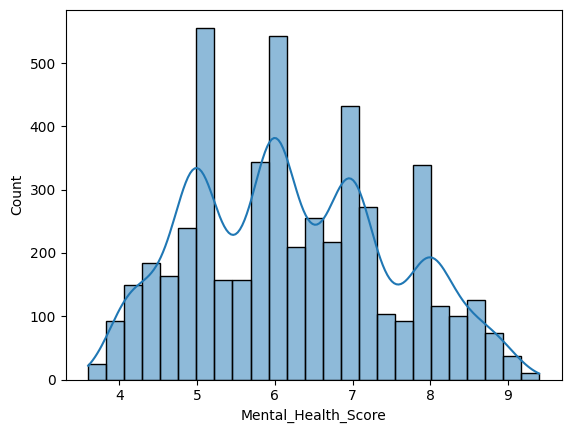

In [10]:
sns.histplot(df["Mental_Health_Score"],kde =True)

<Axes: >

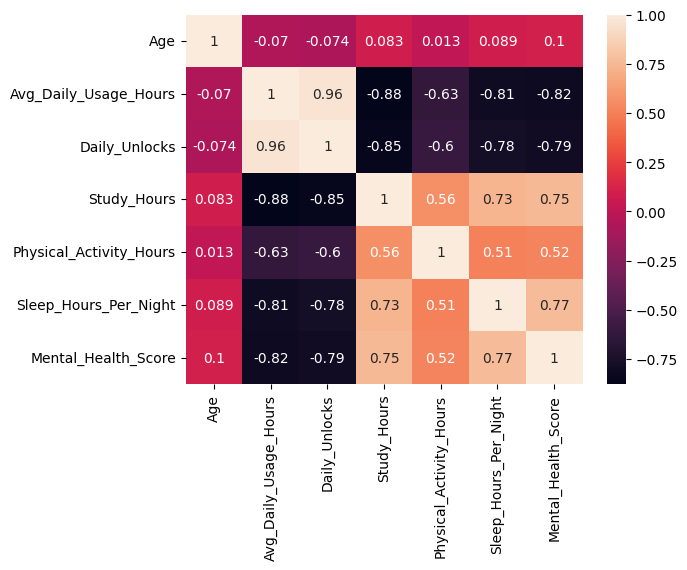

In [11]:
#correlation heatmap
sns.heatmap(df.corr(numeric_only =True),annot =True)

In [12]:


df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

# stress level vs mental health score


In [13]:
df["Stress_Level"].unique()

array(['Medium', 'Low', 'Very High', 'High'], dtype=object)

In [14]:
order =['Low', 'Medium','High', 'Very High']

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

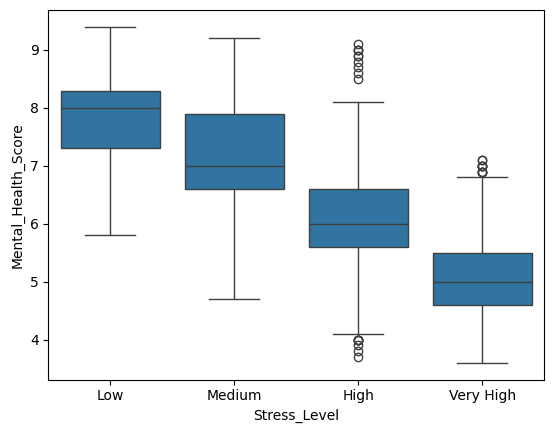

In [15]:
sns.boxplot(x='Stress_Level',y= 'Mental_Health_Score',data = df,order = order)

## Daily Usage Hour vs Mental Health Score

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

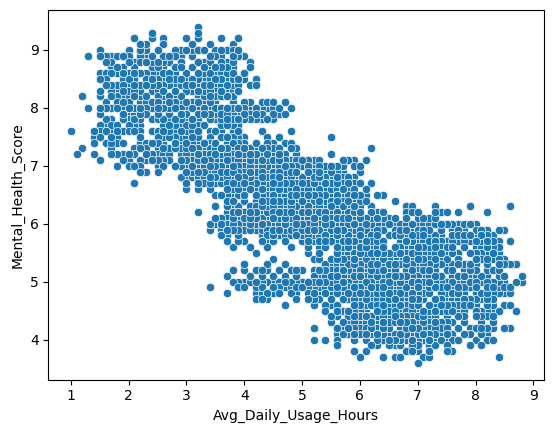

In [16]:
sns.scatterplot(x='Avg_Daily_Usage_Hours',y='Mental_Health_Score',data =df)

## sleep hours vs mental health score

In [17]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Mental_Health_Score'>

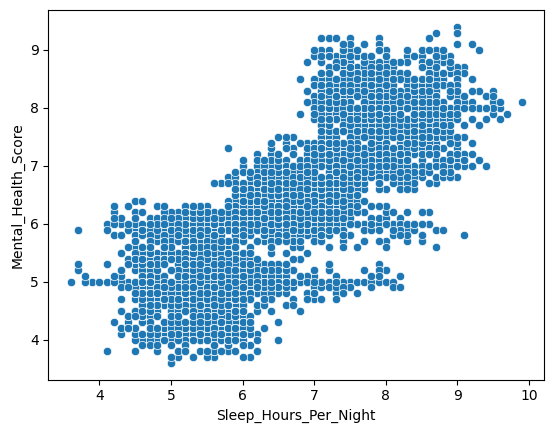

In [18]:
sns.scatterplot(x='Sleep_Hours_Per_Night',y='Mental_Health_Score',data =df)

## most used platform

In [19]:
platform_counts =df["Most_Used_Platform"].value_counts()

In [20]:
platform_counts

Most_Used_Platform
Instagram    1130
TikTok        918
Facebook      719
LinkedIn      523
YouTube       491
Twitter       462
Snapchat      420
WhatsApp      175
LINE           50
VKontakte      40
KakaoTalk      36
WeChat         36
Name: count, dtype: int64

<Axes: xlabel='Most_Used_Platform', ylabel='count'>

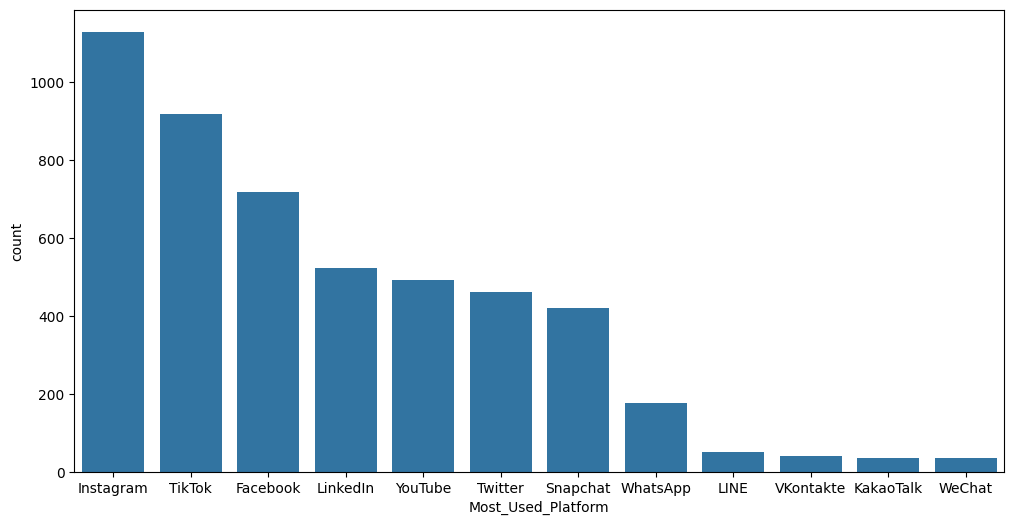

In [21]:
plt.figure(figsize=(12,6))
sns.countplot(x=df["Most_Used_Platform"],order =df["Most_Used_Platform"].value_counts().index)

### checking outliers

In [22]:
num_features = df.select_dtypes(include='number')
num_features

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
0,21,4.0,134,4.5,2.2,6.7,6.8
1,23,1.6,73,7.0,2.4,8.6,7.6
2,22,4.6,166,4.0,1.8,6.7,7.0
3,18,7.0,220,1.0,1.7,5.4,5.3
4,24,7.5,237,1.0,1.1,5.0,4.4
...,...,...,...,...,...,...,...
4995,18,1.9,89,6.1,2.2,7.9,7.9
4996,18,6.6,216,2.3,1.8,6.0,4.7
4997,19,3.8,151,5.4,1.4,7.5,7.0
4998,18,3.8,119,4.0,1.5,6.4,6.7


In [23]:
num_features.columns

Index(['Age', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks', 'Study_Hours',
       'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Mental_Health_Score'],
      dtype='object')

In [24]:
Q1 =num_features.quantile(0.25)
Q3=num_features.quantile(0.75)
IQR = Q3 -Q1

lower_bound =Q1 - (1.5*IQR)
upper_bound =Q3 +( 1.5 *IQR)

outliers =( num_features < lower_bound) | (num_features> upper_bound)
print(outliers.sum())

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


# Data cleaning

In [25]:
#1 to drop duplicate
df = df.drop_duplicates()
#2 converting negative or unrealistic value to realistic value
df['Physical_Activity_Hours']=df['Physical_Activity_Hours'].clip(lower=0)


In [26]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.751160,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.667282,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,0.000000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [27]:
df.shape

(4998, 13)

In [28]:
num_cols =df.select_dtypes(include='number')
num_cols.skew()
# near to 0 -> centralize
# negative -> left skewed
#positive -> right skewed

Age                        0.155008
Avg_Daily_Usage_Hours      0.005575
Daily_Unlocks              0.002309
Study_Hours                0.436125
Physical_Activity_Hours    0.053288
Sleep_Hours_Per_Night      0.123919
Mental_Health_Score        0.207086
dtype: float64

In [29]:
df.columns


Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

In [30]:
top_countries=df["Country"].value_counts().index[:10].tolist()

In [31]:
def group_countries(country):
    if country in top_countries:
        return country
    else:
        return 'Other'

In [32]:
df["Grouped_country"]=df["Country"].apply(group_countries)

In [33]:
df["Grouped_country"].value_counts()

Grouped_country
Other        3231
India         389
USA           354
Canada        230
Australia     198
UK            185
Germany       136
Mexico         94
Turkey         94
France         87
Name: count, dtype: int64

## Train-Test Split

In [34]:
num_cols.columns

Index(['Age', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks', 'Study_Hours',
       'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Mental_Health_Score'],
      dtype='object')

In [35]:
obj_cols =df.select_dtypes(include='object')
obj_cols.columns

Index(['Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Stress_Level', 'Grouped_country'],
      dtype='object')

In [49]:
from sklearn.model_selection import train_test_split
skewed_col =['Study_Hours']
other_numeric_cols = [
    'Age', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
    'Physical_Activity_Hours', 'Sleep_Hours_Per_Night'
    
]
ordinal_col =["Stress_Level"]
nominal_col =['Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Grouped_country']

feature_col =skewed_col + other_numeric_cols + ordinal_col +nominal_col
x=df[feature_col]
y=df['Mental_Health_Score']

x_train,x_test,y_train,y_test =train_test_split(x,y,test_size=0.30,random_state=42)

## build pipeline

In [50]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer,StandardScaler,OrdinalEncoder,OneHotEncoder
from sklearn.compose import ColumnTransformer 
#1 skewed feature
skew_pipeline = Pipeline(steps =[
    ('log_transform',FunctionTransformer(np.log1p)),
    ('scale',StandardScaler())
   
])

#2Numeric Feature
plain_numeric_pipeline = Pipeline(steps=[
    ('scale',StandardScaler())
    
]
    
)


#ordinal  feature
ordinal_pipeline =Pipeline(steps=[
    ('encode',OrdinalEncoder(categories=[['Low', 'Medium', 'High', 'Very High']]))
    
]
    
)


#nominal Feature
nominal_pipeline= Pipeline(steps=[
    ('encode',OneHotEncoder(handle_unknown ='ignore'))
    
]
    
)

preprocessor=ColumnTransformer(transformers=[
    ("Skewed_Pipeline",skew_pipeline,skewed_col),
    ("Plain_Numeric",plain_numeric_pipeline,other_numeric_cols),
    ("Ordinal",ordinal_pipeline,ordinal_col),
    ("Nominal",nominal_pipeline,nominal_col)
])


In [52]:
#linear regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error

lr_pipeline =Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('regressor',LinearRegression())
])


lr_pipeline.fit(x_train,y_train)
lr_preds =lr_pipeline.predict(x_test)
lr_preds_train = lr_pipeline.predict(x_train)
lr_r2_testing = r2_score(y_test,lr_preds)
lr_r2_testing
lr_r2_training= r2_score(y_train,lr_preds_train)
lr_mae = mean_absolute_error(y_test,lr_preds)


print(f"Accuracy of Training: {lr_r2_training}")
print(f"Accuracy of testing: {lr_r2_testing}")
print(f"MAE : {lr_mae}")


Accuracy of Training: 0.7800764399374713
Accuracy of testing: 0.7866985653053776
MAE : 0.47871434560567383


## Random Forest

In [55]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error
rf_pipeline= Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('random forest',RandomForestRegressor(random_state=42))
    
])
rf_pipeline.fit(x_train,y_train)

rf_preds = rf_pipeline.predict(x_test)
rf_preds_training = rf_pipeline.predict(x_train)
rf_r2_testing =r2_score(y_test,rf_preds)
rf_r2_training=r2_score(y_train,rf_preds_training)
rf_mae =mean_absolute_error(y_test,rf_preds)
print(f"Accuracy of training :{rf_r2_training}")
print(f"Accuracy of testing :{rf_r2_testing}")
print(f"MAE : {rf_mae}")


Accuracy of training :0.986072771992374
Accuracy of testing :0.9123700007142354
MAE : 0.2849613000000003


## Hyperparameter Tuning the Random Forest 

In [58]:
from sklearn.model_selection import RandomizedSearchCV
param_grid ={
    "random forest__n_estimators" :[100,200,300],
    "random forest__max_depth":[5,10,15],
    "random forest__min_samples_split":[2,5,10],
    "random forest__min_samples_leaf":[1,2,4]
    
    
}
random_search = RandomizedSearchCV(
    estimator =rf_pipeline,
    param_distributions = param_grid,
    n_iter =15,
    cv=5,
    scoring ="r2",
    random_state =42,
    n_jobs=-1
    
)
random_search.fit(x_train,y_train)





RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('Skewed_Pipeline',
                                                                               Pipeline(steps=[('log_transform',
                                                                                                FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                                               ('scale',
                                                                                                StandardScaler())]),
                                                                               ['Study_Hours']),
                                                                              ('Plain_Numeric',
                                                                               Pipeline(steps=[('scale',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Avg_Daily_Usage_Hours',
                                                                                'Daily_Unlocks',
                                                                                'Ph...
                                                                                'Most_Used_Platform',
                                                                                'Purpose_Of_Use',
                                                                                'Grouped_country'])])),
                                             ('random forest',
                                              RandomForestRegressor(random_state=42))]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'random forest__max_depth': [5, 10, 15],
                                        'random forest__min_samples_leaf': [1,
                                                                            2,
                                                                            4],
                                        'random forest__min_samples_split': [2,
                                                                             5,
                                                                             10],
                                        'random forest__n_estimators': [100,
                                                                        200,
                                                                        300]},
                   random_state=42, scoring='r2')

In [59]:
random_search.best_params_

{'random forest__n_estimators': 300,
 'random forest__min_samples_split': 5,
 'random forest__min_samples_leaf': 2,
 'random forest__max_depth': 15}

In [61]:
rf_best_pipeline =random_search.best_estimator_
rf_best_preds = rf_best_pipeline.predict(x_test)
print(f"R2 Score for random forest after hyperparameter tuning {r2_score(y_test,rf_best_preds)}")
print(f"MAE Score  for random forest after hyperparameter tuning {mean_absolute_error(y_test,rf_best_preds)}")

R2 Score for random forest after hyperparameter tuning 0.8946884197512797
MAE Score  for random forest after hyperparameter tuning 0.31635053819312753


In [63]:
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Evaluation DataFrame
evaluation = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Random Forest (Hyperparameter Tuned)"
    ],
    
    "Training R²": [
        lr_r2_training,
        rf_r2_training,
        r2_score(y_train, rf_best_pipeline.predict(x_train))
    ],
    
    "Testing R²": [
        lr_r2_testing,
        rf_r2_testing,
        r2_score(y_test, rf_best_preds)
    ],
    
    "MAE": [
        lr_mae,
        rf_mae,
        mean_absolute_error(y_test, rf_best_preds)
    ],
    
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_preds)),
        np.sqrt(mean_squared_error(y_test, rf_preds)),
        np.sqrt(mean_squared_error(y_test, rf_best_preds))
    ]
})

# Round values to 4 decimal places
evaluation = evaluation.round(4)

print(evaluation)

                                  Model  Training R²  Testing R²     MAE  \
0                     Linear Regression       0.7801      0.7867  0.4787   
1                         Random Forest       0.9861      0.9124  0.2850   
2  Random Forest (Hyperparameter Tuned)       0.9552      0.8947  0.3164   

     RMSE  
0  0.6121  
1  0.3923  
2  0.4301  


In [64]:
import joblib 
joblib.dump(rf_pipeline,'Mental_Health_Model.pkl')

['Mental_Health_Model.pkl']

In [65]:
import os
print(os.getcwd())

C:\Users\SATYA
